In [73]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import time
import jax.numpy as jnp
import jax

from sklearn.metrics import roc_auc_score

In [74]:
data = pd.read_csv("cs-training.csv")

In [75]:
# removes index column
if "Unnamed: 0" in data.columns:
    data = data.drop("Unnamed: 0", axis=1)
# medians in place of missing values
data = data.fillna(data.median())

# ADD EXTRA CHECKS ON DATA HERE

In [76]:
# separates features and target
target_col = 'SeriousDlqin2yrs'
y = data[target_col].to_numpy()[:, None]
x = data.drop(target_col, axis=1)

In [77]:
# we don't normalize the target
x_mean = x.mean()
x_std = x.std()
x_normalized = (x - x_mean) / x_std
x_normalized_np = x_normalized.to_numpy()

In [78]:
# shuffle
np.random.seed(0)
num_samples = x_normalized_np.shape[0]
indices = np.random.permutation(num_samples)
x_shuffled = x_normalized_np[indices]
y_shuffled = y[indices]

In [79]:
# 80% train, 20% validation
fraction_validation = 0.2
num_train = int(num_samples * (1 - fraction_validation))

x_train = x_shuffled[:num_train]
y_train = y_shuffled[:num_train]
x_valid = x_shuffled[num_train:]
y_valid = y_shuffled[num_train:]

In [80]:
def initialize_params(layers_size):
    np.random.seed(0)
    params = list()
    for i in range(len(layers_size) - 1):
        # Xavier/Glorot Initialization
        W = np.random.randn(layers_size[i + 1], layers_size[i]) * np.sqrt(
            2 / (layers_size[i + 1] + layers_size[i])
        )
        b = np.zeros((layers_size[i + 1], 1))
        params.append((W, b))
    return params

def ANN(x, params):
    layer = x.T
    for i, (W, b) in enumerate(params):
        layer = W @ layer - b
        if i < len(params) - 1:
            layer = activation(layer)
    return layer.T

def loss(x, y, params):
    error = ANN(x, params) - y
    return jnp.mean(error * error)

In [81]:
activation = jnp.tanh

input_size = x_train.shape[1]
layers_size = [input_size, 20, 20, 1]
num_epochs = 200
learning_rate_max = 1e-1
learning_rate_min = 1e-2
learning_rate_decay = num_epochs
batch_size = 1000

params = initialize_params(layers_size)

grad = jax.jit(jax.grad(loss, argnums=2))
loss_jit = jax.jit(loss)
grad_jit = jax.jit(grad)

n_samples = x_train.shape[0]

history_train = list()
history_valid = list()

print("Training...")
t0 = time.time()

for epoch in range(num_epochs):
    lr = max(
        learning_rate_min, learning_rate_max * (1 - epoch / learning_rate_decay)
    )
    perm = np.random.permutation(n_samples)
    for i in range(0, n_samples, batch_size):
        batch_idx = perm[i : i + batch_size]
        x_batch = x_train[batch_idx]
        y_batch = y_train[batch_idx]
        grads = grad_jit(x_batch, y_batch, params)
        params = jax.tree_util.tree_map(lambda p, g: p - lr * g, params, grads)

    history_train.append(loss_jit(x_train, y_train, params))
    history_valid.append(loss_jit(x_valid, y_valid, params))

print("Elapsed time: %f s" % (time.time() - t0))
print("Train loss : %1.3e" % history_train[-1])
print("Validation loss: %1.3e" % history_valid[-1])

Training...
Elapsed time: 52.247191 s
Train loss : 5.079e-02
Validation loss: 4.979e-02


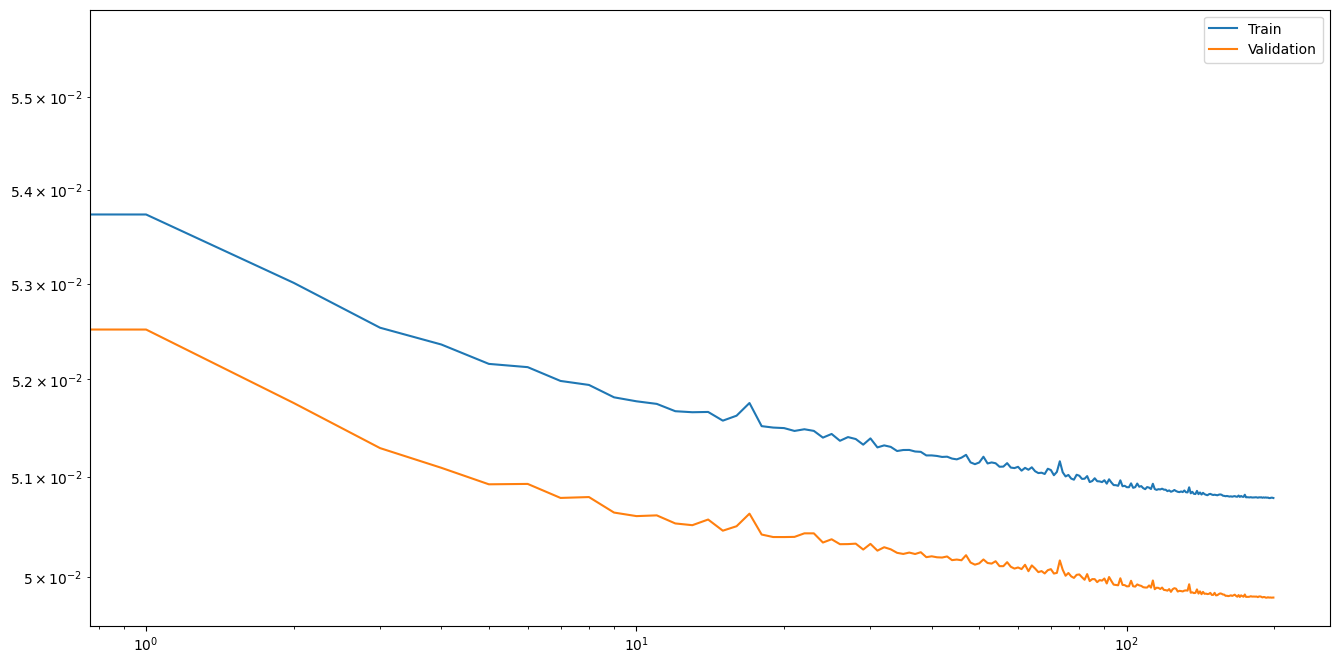

In [82]:
fig, axs = plt.subplots(1, figsize=(16, 8))
axs.loglog(history_train, label="Train")
axs.loglog(history_valid, label="Validation")
plt.legend()

In [83]:
y_pred_valid = ANN(x_valid, params)
# y_valid are binary, y_pred_valid are continuous
auc_score = roc_auc_score(y_valid, y_pred_valid)
print(f"AUC: {auc_score:.5f}")

AUC: 0.83475


In [84]:
data_test = pd.read_csv("cs-test.csv")
if "Unnamed: 0" in data_test.columns:
    data_test = data_test.drop("Unnamed: 0", axis=1)
data_test = data_test.fillna(data.median())

x_test = data_test.drop(target_col, axis=1)
x_test_norm = (x_test - x_mean) / x_std
x_test_np = x_test_norm.to_numpy()
predictions_test = ANN(x_test_np, params)